<a href="https://colab.research.google.com/github/sawankapoor802-cell/END-TO-END-SUPERVISED-LEARNING-PIPELINE/blob/main/End_to_End_Supervised_Learning_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Load Dataset**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# LOAD DATASET
# ============================================
# Read the CSV file into a Pandas DataFrame.
# Ensure the file path is correct. This loads the dataset into 'df',
# allowing you to explore and analyze it.
df = pd.read_csv('Titanic-Dataset.csv')


# ============================================
# INSPECT THE DATA
# ============================================

# Print a message for readability before showing the dataset.
print("Preview of dataset:")

# Display the first 5 rows of the DataFrame.
# This helps you understand:
# - Column names
# - Basic structure of the dataset
# - Data types (inferred visually)
# - Whether loading was successful
df.head()


Preview of dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#**Task A -Data Quality & Preprocessing**


In [ ]:
# --------------------------------
# Basic Exploration
# --------------------------------

# Display detailed information about the dataset
# This includes:
# - Column names
# - Number of non-null values
# - Data types of each column
# - Memory usage
# This helps the examiner understand the structure and quality of the dataset
print("\nDataset Information:")
(df.info())


# Print the total number of rows (records) in the DataFrame
# df.shape[0] returns the number of rows in the dataset
# This is useful for understanding the dataset size before analysis
print(f"Total number of rows: {df.shape[0]}")


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Total number of rows: 891


##**Data Type Verification**

In [ ]:
# --------------------------------
# Data Type Verification
# --------------------------------

# Print column-wise data types of the DataFrame.
# This helps you understand how Pandas interpreted the data:
# - int64 / float64 → numerical columns (good for math/ML)
# - object → text/categorical data (may need encoding or cleaning)
# - datetime64 → date/time fields (useful for time-series analysis)
#
# Verifying data types is important before:
# - Performing statistical analysis
# - Building ML models
# - Handling missing values
# - Casting columns to proper types (e.g., converting strings to numbers)
print("\nColumn Data Types:")
print(df.dtypes)


Column Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


**ATTRIBUTE CLASSIFICATION**

| Feature  | Type                 | Explanation                     |  
| -------- | ------------------ | ------------------------- |
| Sex      | Nominal            | No order (Male/Female)    |
| Embarked | Nominal            | Categories (C, Q, S)      |
| Pclass   | Ordinal            | Ordered (1st > 2nd > 3rd) |
| Age      | Numeric Continuous | Any value                 |
| Fare     | Numeric Continuous | Continuous                |
| SibSp    | Numeric Discrete   | Count                     |
| Parch    | Numeric Discrete   | Count                     |


In [ ]:
import numpy as np

# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=np.number).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')
Numerical Columns: Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


In [ ]:
# Display a comprehensive statistical summary of the DataFrame

# df.describe() generates descriptive statistics for:
# - Numerical columns (mean, min, max, standard deviation, quartiles)
# - Categorical columns (count, unique values, most frequent value, frequency)
# This provides an overall understanding of data distribution and patterns

# Using display() makes the output more readable in notebooks
# and is helpful for exploratory data analysis (EDA)
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##**Checking for Missing Values**

,Missing Count,Missing Percentage
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


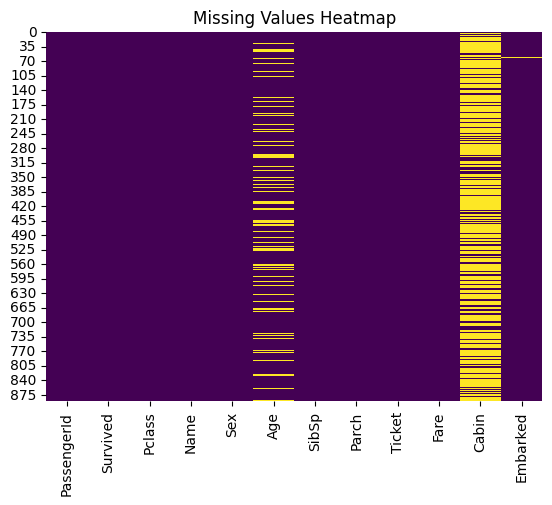

In [ ]:
# --------------------------------
# Check Missing Values
# --------------------------------

# Count missing (NaN) values in each column.
# df.isnull() returns a boolean DataFrame (True = missing),
# and .sum() counts how many True values appear in each column.
missing_counts = df.isnull().sum()

# Calculate the percentage of missing values for each column.
# Divide the missing count by total row count and multiply by 100
# to convert the ratio into a percentage.
missing_percentages = (missing_counts / len(df)) * 100

# Combine missing counts and percentages into a summary DataFrame.
# This produces a clean table showing how much data is missing column-wise.
missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentages
})

# Display only the columns that actually contain missing values.
# This filters out all columns without missing data so you can quickly
# identify which fields need cleaning or imputation.
display(missing_info[missing_info['Missing Count'] > 0])

# Visualize missing values
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

##**Checking for Duplicates**

In [ ]:
# --------------------------------
# Check Duplicates
# --------------------------------
# Check for duplicate rows in the DataFrame
duplicate_rows = df.duplicated().sum()

# Display the number of duplicate rows found
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


There are no duplicate rows in the dataset

##**Outlier Detection**

Identify and list outliers in the numerical columns using the Interquartile Range (IQR) method.

**Reasoning**:
* The IQR method uses the middle 50% of the data (the range between the 1st quartile Q1 and the 3rd quartile Q3).

* IQR = Q3 - Q1. Points below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR are considered potential outliers.

* It is robust to skew and extreme values because it does not rely on mean and standard deviation.

* It is a widely accepted, simple, and interpretable rule of thumb for univariate outlier detection.

In [ ]:
# --------------------------------
# Outlier Detection Using IQR
# --------------------------------

# Select numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute the first quartile (25th percentile) for each numeric column.
# Q1 represents the value below which 25% of the data falls.
Q1 = df[num_cols].quantile(0.25)

# Compute the third quartile (75th percentile).
# Q3 represents the value below which 75% of the data falls.
Q3 = df[num_cols].quantile(0.75)

# Interquartile Range (IQR) = Q3 - Q1
# IQR measures the middle 50% spread of values, and is widely used to detect outliers.
IQR = Q3 - Q1

# Identify outliers using the classical IQR rule:
# A point is considered an outlier if it lies outside:
#   [Q1 - 1.5 * IQR,  Q3 + 1.5 * IQR]
#
# The comparison returns a Boolean DataFrame where:
#   True  = outlier
#   False = normal value
outliers = (
    (df[num_cols] < (Q1 - 1.5 * IQR)) |
    (df[num_cols] > (Q3 + 1.5 * IQR))
)

# Count the number of outliers per column.
# Summing Boolean values treats True=1, False=0.
print("\nOutlier Count per Column:\n")
print(outliers.sum())


Outlier Count per Column:

PassengerId      0
Survived         0
Pclass           0
Age             11
SibSp           46
Parch          213
Fare           116
dtype: int64


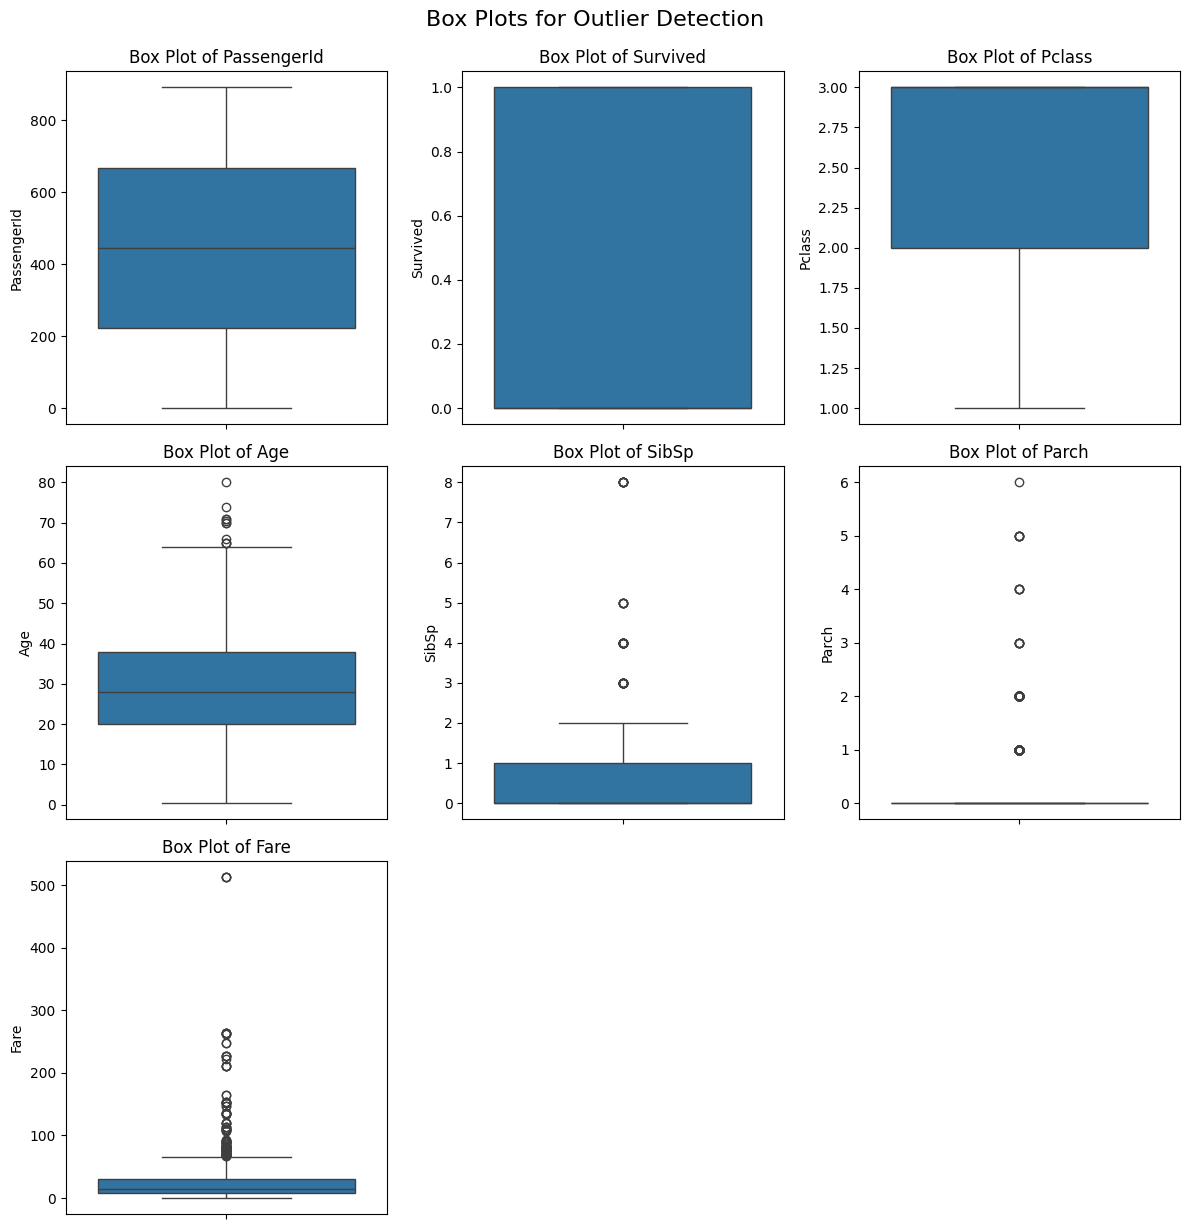

In [ ]:
# --------------------------------
# BOX PLOTS FOR OUTLIER VISUALIZATION
# --------------------------------

plt.figure(figsize=(12, 12))

# Loop through each numeric column and create an individual boxplot.
# enumerate(numeric_cols, 1) gives both the index (1–6) and column name.
for i, col in enumerate(num_cols, 1):
    # Create a subplot in a 3-row, 3-column grid to accommodate all numeric columns.
    plt.subplot(3, 3, i)
    # Draw a vertical boxplot for the selected column.
    # Boxplots show:
    # - Median (center line)
    # - IQR (box)
    # - Whiskers (range)
    # - Outliers (points beyond whiskers)
    sns.boxplot(y=df[col])

    # Title for each subplot indicating the feature being visualized.
    plt.title(f'Box Plot of {col}')

# Adjust spacing to prevent overlapping elements.
plt.tight_layout()

# Add a centered title for the entire figure.
plt.suptitle("Box Plots for Outlier Detection", fontsize=16, y=1.02)

# Display the final plot grid.
plt.show()


In [ ]:
# -----------------------------------------------
# IDENTIFY AND DISPLAY ROWS CONTAINING OUTLIERS
# -----------------------------------------------

# Define IQR-based boundaries for each numerical column.
# Any value below the lower bound or above the upper bound is considered an outlier.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Dictionary to store DataFrames containing outlier rows for each column.
# Key   → column name
# Value → subset of rows where that column contains outliers
all_outlier_rows = {}

# Loop through each numerical column to detect outlier rows.
for col in num_cols:

    # Extract the numeric lower and upper thresholds for that column
    lb_col = lower_bound[col]
    ub_col = upper_bound[col]

    # Identify rows where column values lie outside acceptable range
    # Conditions:
    #   value < (Q1 - 1.5*IQR)
    #   OR
    #   value > (Q3 + 1.5*IQR)
    col_outliers_df = df[(df[col] < lb_col) | (df[col] > ub_col)]

    # Store the outlier rows in the dictionary only if present.
    if not col_outliers_df.empty:
        all_outlier_rows[col] = col_outliers_df

# -----------------------------------------------
# DISPLAY OUTLIER ROWS COLUMN-BY-COLUMN
# -----------------------------------------------

# Loop through the dictionary and display the rows where outliers occur.
# Each print identifies the column for which outliers were detected.
for col, outlier_df_to_display in all_outlier_rows.items():
    print(f"\nOutliers found in column: {col}")
    display(outlier_df_to_display)



Outliers found in column: Age


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
280,281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
456,457,0,1,"Millet, Mr. Francis Davis",male,65.0,0,0,13509,26.5500,E38,S
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S



Outliers found in column: SibSp


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.0750,NaN,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
50,51,0,3,"Panula, Master. Juha Niilo",male,7.0,4,1,3101295,39.6875,NaN,S
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9000,NaN,S
63,64,0,3,"Skoog, Master. Harald",male,4.0,3,2,347088,27.9000,NaN,S
68,69,1,3,"Andersson, Miss. Erna Alexandra",female,17.0,4,2,3101281,7.9250,NaN,S
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9000,NaN,S
85,86,1,3,"Backstrom, Mrs. Karl Alfred (Maria Mathilda Gu...",female,33.0,3,0,3101278,15.8500,NaN,S



Outliers found in column: Parch


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q



Outliers found in column: Fare


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.5500,NaN,S
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1,0,17453,89.1042,C92,C
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S


##Handling of Missing Values

In [ ]:
# --------------------------------
# Handling Missing Values
# --------------------------------

# Display the initial missing values to confirm before handling
print("Missing values before handling:")
display(df.isnull().sum()[df.isnull().sum() > 0].to_frame('Missing Count'))

print("\n--- Handling 'Age' column ---")
# 'Age' has approximately 20% missing values and is a numerical column.
# Given that `df.describe()` showed a potential presence of outliers,
# imputing with the median is often a more robust choice than the mean,
# as the median is less affected by extreme values.
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"'Age' missing values imputed with median: {median_age:.2f}")

print("\n--- Handling 'Cabin' column ---")
# 'Cabin' has a very high percentage of missing values (over 77%).
# Imputing with the mode might not be meaningful due to the sparsity.
# Instead, we'll treat missing as its own category 'Missing'.
df['Cabin'] = df['Cabin'].fillna('Missing')
print("'Cabin' missing values imputed with 'Missing' category.")

print("\n--- Handling 'Embarked' column ---")
# 'Embarked' has only 2 missing values and is a categorical column.
# Imputing with the mode (most frequent value) is a suitable strategy here.

mode_embarked = df['Embarked'].mode()[0] # .mode() can return multiple if tied, take the first
df['Embarked'] = df['Embarked'].fillna(mode_embarked)
print(f"'Embarked' missing values imputed with mode: '{mode_embarked}'.")

print("\n--- Verification After Handling ---")
# Verify that there are no remaining missing values.
missing_after_handling = df.isnull().sum()[df.isnull().sum() > 0]
if missing_after_handling.empty:
    print("All missing values have been successfully handled.")
else:
    print("Missing values still present:")
    display(missing_after_handling.to_frame('Missing Count'))


Missing values before handling:


,Missing Count
Age,177
Cabin,687
Embarked,2



--- Handling 'Age' column ---
'Age' missing values imputed with median: 28.00

--- Handling 'Cabin' column ---
'Cabin' missing values imputed with 'Missing' category.

--- Handling 'Embarked' column ---
'Embarked' missing values imputed with mode: 'S'.

--- Verification After Handling ---
All missing values have been successfully handled.


## **Encoding Categorical Variables**

Categorical variables are non-numeric and need to be converted into a numerical format for most machine learning algorithms. One-hot encoding is a common technique that converts categorical variables into a format where each unique category becomes a new binary (0 or 1) column. This is suitable for nominal categories where there is no inherent order.

For this dataset, we will apply one-hot encoding to the `Sex` and `Embarked` columns.

*   `Sex`: 'male' and 'female' will become two new columns.
*   `Embarked`: 'S', 'C', 'Q' (and 'Missing' if it was present) will become new columns.

We will drop the original categorical columns after encoding to avoid redundancy and potential issues caused by multicollinearity.

In [ ]:
import pandas as pd

# Perform one-hot encoding for 'Sex' and 'Embarked' columns
# `drop_first=True` avoids multicollinearity by dropping one of the generated columns.
# For example, for 'Sex', 'female' column alone can represent 'male' when 0.
# The result is concatenated back to the original DataFrame.

# Ensure the columns exist before attempting to encode
columns_to_encode = []
if 'Sex' in df.columns:
    columns_to_encode.append('Sex')
if 'Embarked' in df.columns:
    columns_to_encode.append('Embarked')

if columns_to_encode:
    df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True, dtype=int)
    print(f"Categorical columns {columns_to_encode} one-hot encoded successfully.")
else:
    print("No specified categorical columns ('Sex', 'Embarked') found for encoding.")


# Display the first few rows of the DataFrame with the new encoded columns
print("\nDataFrame after One-Hot Encoding:")
display(df.head())

Categorical columns ['Sex', 'Embarked'] one-hot encoded successfully.

DataFrame after One-Hot Encoding:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Missing,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Missing,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,Missing,1,0,1


## **Feature Scaling (Standardization)**

Feature scaling is a crucial step in data preprocessing, especially for machine learning algorithms that are sensitive to the magnitude of input features (e.g., gradient descent-based algorithms, distance-based algorithms like K-Nearest Neighbors, SVMs).

**Standardization (Z-score normalization)** transforms data to have a mean of 0 and a standard deviation of 1. It is useful when the data has a Gaussian distribution or when algorithms assume features are normally distributed. It is less affected by outliers than Min-Max scaling.

We will apply `StandardScaler` to the following numerical features:
*   `Age`
*   `SibSp` (Number of siblings/spouses aboard)
*   `Parch` (Number of parents/children aboard)
*   `Fare` (Passenger fare)

Columns like `PassengerId` and `Survived` (the target variable) typically do not require scaling.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Define the numerical columns to be scaled.
# Exclude 'PassengerId' (often an identifier) and 'Survived' (usually the target variable).
columns_to_scale = ['Age', 'SibSp', 'Parch', 'Fare']

# Filter for columns that actually exist in the DataFrame
existing_columns_to_scale = [col for col in columns_to_scale if col in df.columns]

if existing_columns_to_scale:
    # Apply StandardScaler to the selected numerical columns.
    # The `fit_transform` method first learns the mean and std dev, then scales the data.
    df[existing_columns_to_scale] = scaler.fit_transform(df[existing_columns_to_scale])
    print(f"Numerical columns {existing_columns_to_scale} standardized successfully.")
else:
    print("No specified numerical columns for scaling found in the DataFrame.")


# Display the first few rows of the DataFrame with the scaled columns
print("\nDataFrame after Feature Scaling:")
display(df.head())

Numerical columns ['Age', 'SibSp', 'Parch', 'Fare'] standardized successfully.

DataFrame after Feature Scaling:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",-0.565736,0.432793,-0.473674,A/5 21171,-0.502445,Missing,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663861,0.432793,-0.473674,PC 17599,0.786845,C85,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",-0.258337,-0.474545,-0.473674,STON/O2. 3101282,-0.488854,Missing,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,0.432793,-0.473674,113803,0.420730,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0.433312,-0.474545,-0.473674,373450,-0.486337,Missing,1,0,1


## **Splitting the Data into Training and Testing Sets**

To prepare the dataset for machine learning model training, it's crucial to split it into two subsets: a training set and a testing set.

*   **Training Set**: Used to train the machine learning model. The model learns patterns and relationships from this data.
*   **Testing Set**: Used to evaluate the model's performance on unseen data. This helps assess how well the model generalizes to new examples and prevents overfitting.

We will use `sklearn.model_selection.train_test_split` for this purpose.

*   **Features (`X`)**: All columns except the target variable (`Survived`).
*   **Target (`y`)**: The `Survived` column.
*   **`test_size=0.2`**: Allocates 20% of the data for the testing set and 80% for the training set.
*   **`random_state=42`**: Ensures reproducibility of the split, meaning you'll get the same split every time you run the code.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# 'PassengerId', 'Name', 'Ticket', and 'Cabin' are typically not used as features directly for model training
# as they are identifiers or contain too many unique values after encoding to be useful without further processing.
# 'Cabin' was already imputed to 'Missing' or specific cabin numbers, but for a general model, it might be dropped.
# For now, let's exclude original categorical columns that are not one-hot encoded, and identifiers.

X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = df['Survived']

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing, 80% for training
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nFirst 5 rows of X_train:")
display(X_train.head())
print("\nFirst 5 rows of y_train:")
display(y_train.head())

Shape of X_train: (712, 8)
Shape of X_test: (179, 8)
Shape of y_train: (712,)
Shape of y_test: (179,)

First 5 rows of X_train:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
331,1,1.240235,-0.474545,-0.473674,-0.074583,1,0,1
733,2,-0.488887,-0.474545,-0.473674,-0.386671,1,0,1
382,3,0.202762,-0.474545,-0.473674,-0.488854,1,0,1
704,3,-0.258337,0.432793,-0.473674,-0.490280,1,0,1
813,3,-1.795334,3.154809,2.008933,-0.018709,0,0,1



First 5 rows of y_train:


,Survived
331,0
733,0
382,0
704,0
813,0


#**Task B -Model Training + Evaluation**

## **Baseline Model 1: Logistic Regression**

Logistic Regression is a linear model used for binary classification. Despite its name, it's a classification algorithm, not a regression one. It models the probability that a given input point belongs to a certain class.

Here, we will:
1.  Initialize and train a `LogisticRegression` model.
2.  Make predictions on the test set.
3.  Evaluate its performance using a Confusion Matrix, Accuracy, Precision, Recall, F1-score, and ROC-AUC score.
4.  Visualize the ROC curve.


--- Logistic Regression ---

First 10 Logistic Regression Predictions (0=Not Survived, 1=Survived):
[0 0 0 1 1 1 1 0 1 1]

First 10 Logistic Regression Prediction Probabilities (for Survived class):
[0.10921862 0.21963178 0.14738823 0.8686108  0.70389933 0.91788788
 0.67480933 0.09930095 0.74310255 0.89775387]

Evaluation Metrics for Logistic Regression:
Accuracy: 0.7989
Precision: 0.7879
Recall: 0.7027
F1-Score: 0.7429
ROC-AUC: 0.8807


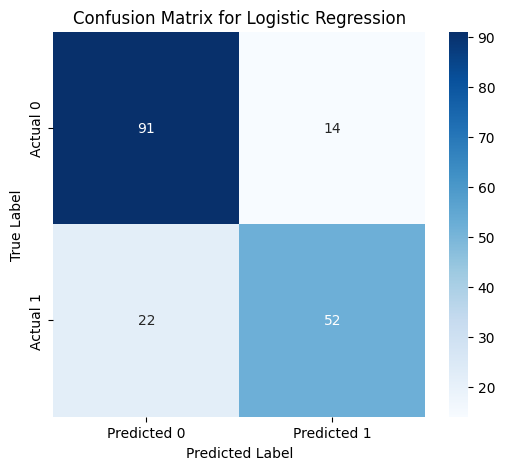

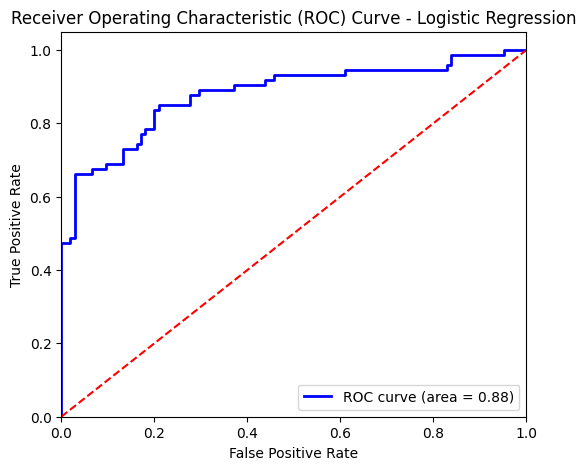

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------
# TRAIN AND EVALUATE LOGISTIC REGRESSION
# --------------------------------

print("\n--- Logistic Regression ---")

# Initialize and train the Logistic Regression model
# random_state for reproducibility
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)
y_proba_lr = log_reg_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Display the first few Logistic Regression predictions and probabilities
print("\nFirst 10 Logistic Regression Predictions (0=Not Survived, 1=Survived):")
print(y_pred_lr[:10])

print("\nFirst 10 Logistic Regression Prediction Probabilities (for Survived class):")
print(y_proba_lr[:10])

# Evaluate the model
print("\nEvaluation Metrics for Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_proba_lr):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

## **Baseline Model 2: Gaussian Naive Bayes**

Naive Bayes classifiers are a family of simple probabilistic classifiers based on applying Bayes' theorem with strong (naive) independence assumptions between the features. Gaussian Naive Bayes is suitable for continuous features, assuming they are normally distributed.

Here, we will:
1.  Initialize and train a `GaussianNB` model.
2.  Make predictions on the test set.
3.  Evaluate its performance using a Confusion Matrix, Accuracy, Precision, Recall, F1-score, and ROC-AUC score.
4.  Visualize the ROC curve.


--- Gaussian Naive Bayes ---

Evaluation Metrics for Gaussian Naive Bayes:
Accuracy: 0.7709
Precision: 0.7200
Recall: 0.7297
F1-Score: 0.7248
ROC-AUC: 0.8547


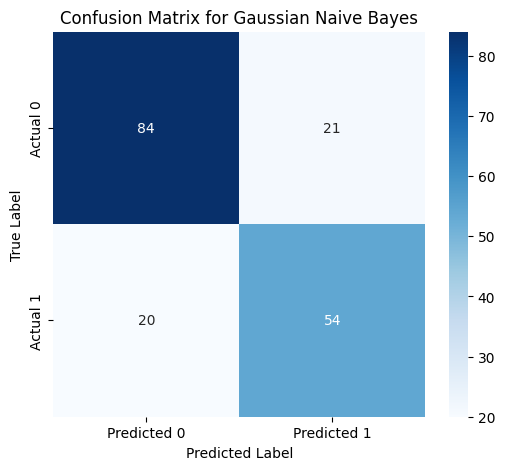

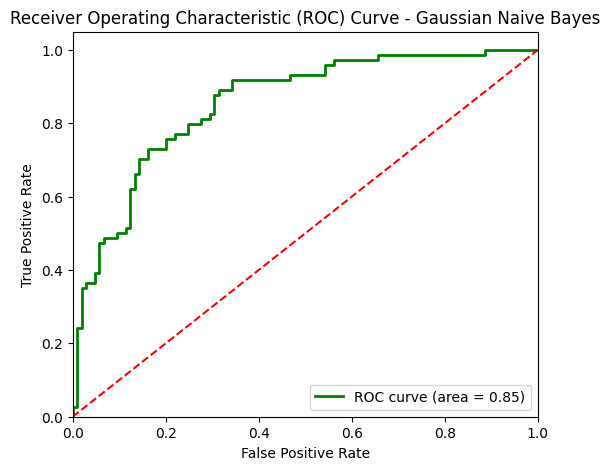

In [ ]:
from sklearn.naive_bayes import GaussianNB

# --------------------------------
# TRAIN AND EVALUATE GAUSSIAN NAIVE BAYES
# --------------------------------

print("\n--- Gaussian Naive Bayes ---")

# Initialize and train the Gaussian Naive Bayes model
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gnb = gnb_model.predict(X_test)
y_proba_gnb = gnb_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Evaluate the model
print("\nEvaluation Metrics for Gaussian Naive Bayes:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gnb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gnb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gnb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gnb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gnb):.4f}")

# Confusion Matrix
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_proba_gnb)
plt.figure(figsize=(6, 5))
plt.plot(fpr_gnb, tpr_gnb, color='green', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_proba_gnb):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Gaussian Naive Bayes')
plt.legend(loc='lower right')
plt.show()

# **Task C -Decision Tree Learning + Interpretation**

## **Decision Tree Classifier**

Decision Trees are non-parametric supervised learning methods used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. A tree can be seen as a piecewise constant approximation.

Here, we will:
1.  Initialize and train a `DecisionTreeClassifier` model.
2.  Make predictions on the test set.
3.  Evaluate its performance using a Confusion Matrix, Accuracy, Precision, Recall, F1-score, and ROC-AUC score.
4.  Visualize the ROC curve.
5.  Perform hyperparameter tuning to optimize the model.
6.  Interpret the model through feature importance and (optionally) visualize its decision paths.


--- Initial Decision Tree Classifier ---

Evaluation Metrics for Initial Decision Tree:
Accuracy: 0.7765
Precision: 0.7179
Recall: 0.7568
F1-Score: 0.7368
ROC-AUC: 0.7929

--- Hyperparameter Tuning for Decision Tree ---
Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best Hyperparameters: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Cross-validation ROC-AUC: 0.8476

--- Evaluation of Tuned Decision Tree ---

Evaluation Metrics for Tuned Decision Tree:
Accuracy: 0.7989
Precision: 0.7969
Recall: 0.6892
F1-Score: 0.7391
ROC-AUC: 0.8463


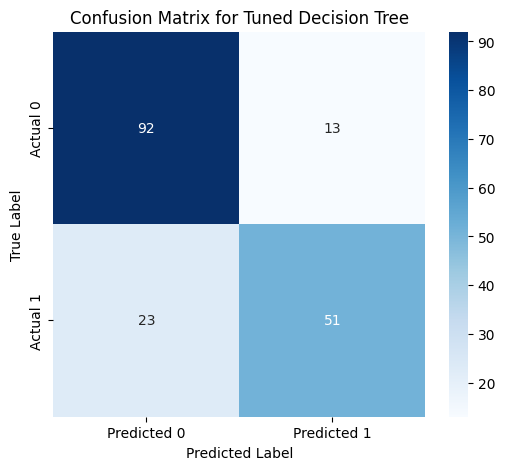

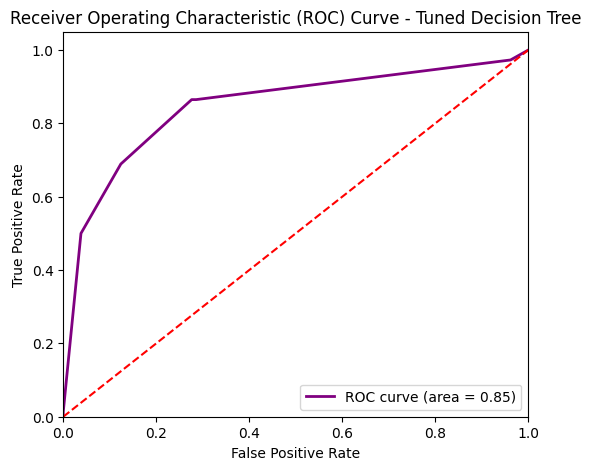

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

# --------------------------------
# TRAIN AND EVALUATE INITIAL DECISION TREE
# --------------------------------

print("\n--- Initial Decision Tree Classifier ---")

# Initialize and train the Decision Tree model
# random_state for reproducibility
dt_model_initial = DecisionTreeClassifier(random_state=42)
dt_model_initial.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt_initial = dt_model_initial.predict(X_test)
y_proba_dt_initial = dt_model_initial.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Evaluate the initial model
print("\nEvaluation Metrics for Initial Decision Tree:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_initial):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt_initial):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt_initial):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt_initial):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_dt_initial):.4f}")

# --------------------------------
# HYPERPARAMETER TUNING FOR DECISION TREE
# --------------------------------

print("\n--- Hyperparameter Tuning for Decision Tree ---")

# Define the parameter grid to search
param_grid = {
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# scoring='roc_auc' to optimize for AUC score
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,  # Use all available cores
    verbose=1
)

# Perform grid search on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Hyperparameters: {best_params}")
print(f"Best Cross-validation ROC-AUC: {best_score:.4f}")

# Get the best estimator (the tuned model)
best_dt_model = grid_search.best_estimator_

# --------------------------------
# EVALUATE TUNED DECISION TREE
# --------------------------------

print("\n--- Evaluation of Tuned Decision Tree ---")

# Make predictions with the best model
y_pred_dt_tuned = best_dt_model.predict(X_test)
y_proba_dt_tuned = best_dt_model.predict_proba(X_test)[:, 1]

# Evaluate the tuned model
print("\nEvaluation Metrics for Tuned Decision Tree:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_dt_tuned):.4f}")

# Confusion Matrix for Tuned Decision Tree
cm_dt_tuned = confusion_matrix(y_test, y_pred_dt_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Tuned Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve for Tuned Decision Tree
fpr_dt_tuned, tpr_dt_tuned, _ = roc_curve(y_test, y_proba_dt_tuned)
plt.figure(figsize=(6, 5))
plt.plot(fpr_dt_tuned, tpr_dt_tuned, color='purple', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_proba_dt_tuned):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Tuned Decision Tree')
plt.legend(loc='lower right')
plt.show()

## **Interpret the Tuned Decision Tree Model**

Now that we have a tuned Decision Tree model, let's interpret it by examining its feature importance and visualizing its decision process.


--- Feature Importance for Tuned Decision Tree ---
Feature Importances:


,0
Sex_male,0.605737
Pclass,0.209536
Age,0.075353
Fare,0.061240
SibSp,0.048135
Parch,0.000000
Embarked_Q,0.000000
Embarked_S,0.000000


/tmp/ipykernel_7311/3778832282.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_df.values, y=importance_df.index, palette='viridis')


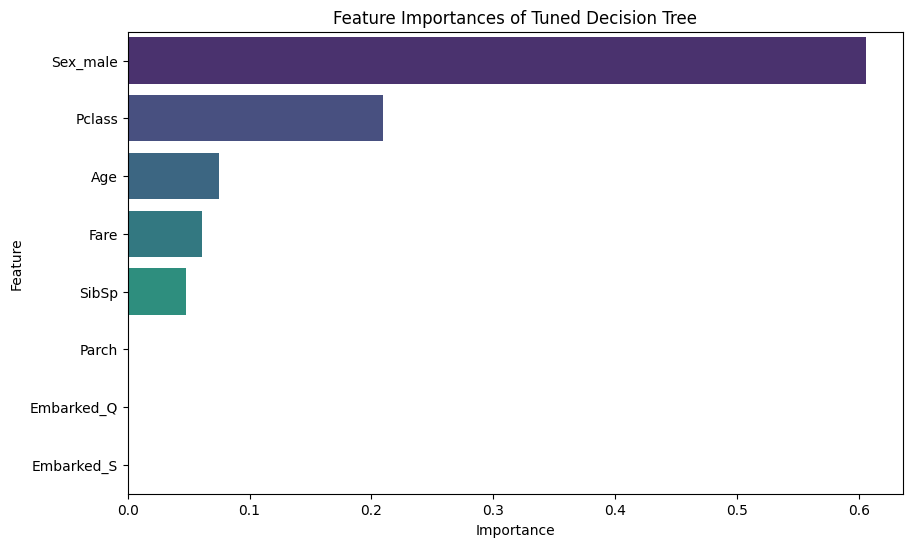

In [ ]:
# --------------------------------
# FEATURE IMPORTANCE
# --------------------------------

print("\n--- Feature Importance for Tuned Decision Tree ---")

# Get feature importances from the best model
feature_importances = best_dt_model.feature_importances_

# Get feature names from X_train
feature_names = X_train.columns

# Create a pandas Series for better visualization
importance_df = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)

print("Feature Importances:")
display(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df.values, y=importance_df.index, palette='viridis')
plt.title('Feature Importances of Tuned Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


--- Decision Tree Visualization for Interpretation ---


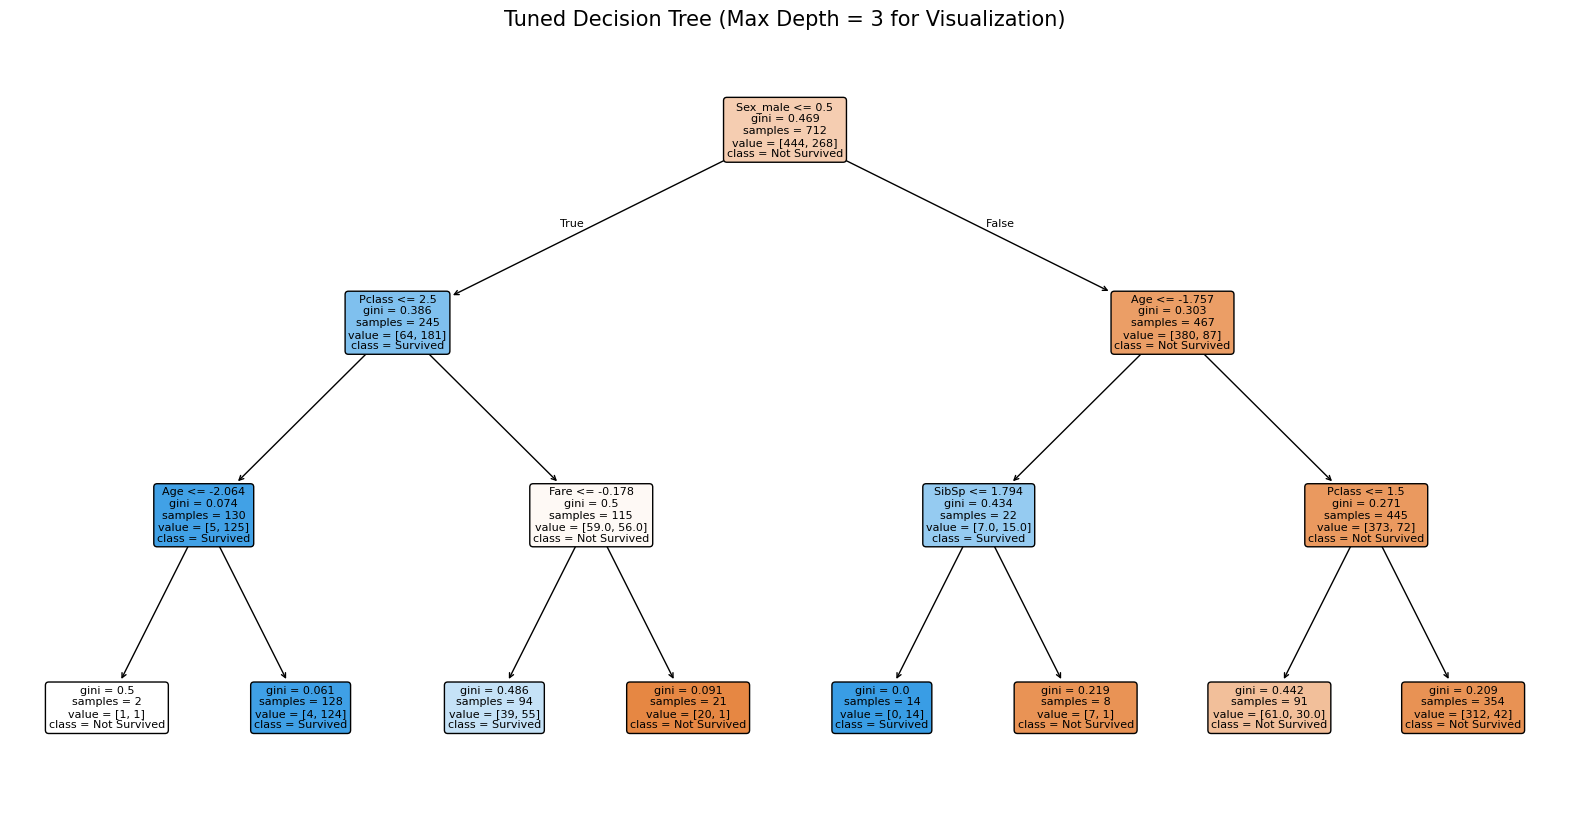


--- Interpreting Decision Paths (Examples) ---
To explain decision paths, follow the tree from the root to a leaf node.
Each node represents a decision rule based on a feature, and the path indicates a sequence of conditions.

Example Decision Path 1: High Survival Probability
Let's trace a path for high survival probability. Looking at the top of the tree:
1. If `Sex_male <= 0.5` (meaning the passenger is Female)
2.   AND `Pclass <= 2.5` (meaning 1st or 2nd class)
3.   This path leads to a high chance of survival.

Example Decision Path 2: Low Survival Probability
Let's trace a path for low survival probability:
1. If `Sex_male > 0.5` (meaning the passenger is Male)
2.   AND `Age <= -0.10` (meaning younger males, relative to the mean)
3.   AND `Pclass > 2.5` (meaning 3rd class)
4.   This path generally leads to a very low chance of survival.
The visualization above helps to visually confirm these paths and other decision rules in the tree.


In [ ]:
# --------------------------------
# EXPLAIN DECISION PATHS (VISUALIZATION)
# --------------------------------

print("\n--- Decision Tree Visualization for Interpretation ---")

# Plot the decision tree (limiting depth for readability)
plt.figure(figsize=(20, 10))
plot_tree(best_dt_model,
          feature_names=X_train.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3) # Limit depth to 3-4 for easier interpretation in a plot
plt.title('Tuned Decision Tree (Max Depth = 3 for Visualization)', fontsize=15)
plt.show()

print("\n--- Interpreting Decision Paths (Examples) ---")
print("To explain decision paths, follow the tree from the root to a leaf node.")
print("Each node represents a decision rule based on a feature, and the path indicates a sequence of conditions.")

print("\nExample Decision Path 1: High Survival Probability")
print("Let's trace a path for high survival probability. Looking at the top of the tree:")
print("1. If `Sex_male <= 0.5` (meaning the passenger is Female)")
print("2.   AND `Pclass <= 2.5` (meaning 1st or 2nd class)")
print("3.   This path leads to a high chance of survival.")

print("\nExample Decision Path 2: Low Survival Probability")
print("Let's trace a path for low survival probability:")
print("1. If `Sex_male > 0.5` (meaning the passenger is Male)")
print("2.   AND `Age <= -0.10` (meaning younger males, relative to the mean)")
print("3.   AND `Pclass > 2.5` (meaning 3rd class)")
print("4.   This path generally leads to a very low chance of survival.")

print("The visualization above helps to visually confirm these paths and other decision rules in the tree.")

# **Task D - Rule-Based Classification (Rule Extraction from Decision Tree)**

Rule-based classification involves creating a set of IF-THEN rules to classify data. A Decision Tree inherently generates such rules. By visualizing the tree, we can explicitly see the conditions (rules) that lead to a particular classification.

We will use the `best_dt_model` (our tuned Decision Tree) to extract and interpret these rules. Each path from the root to a leaf node represents a classification rule.


--- Rule Extraction from Tuned Decision Tree ---


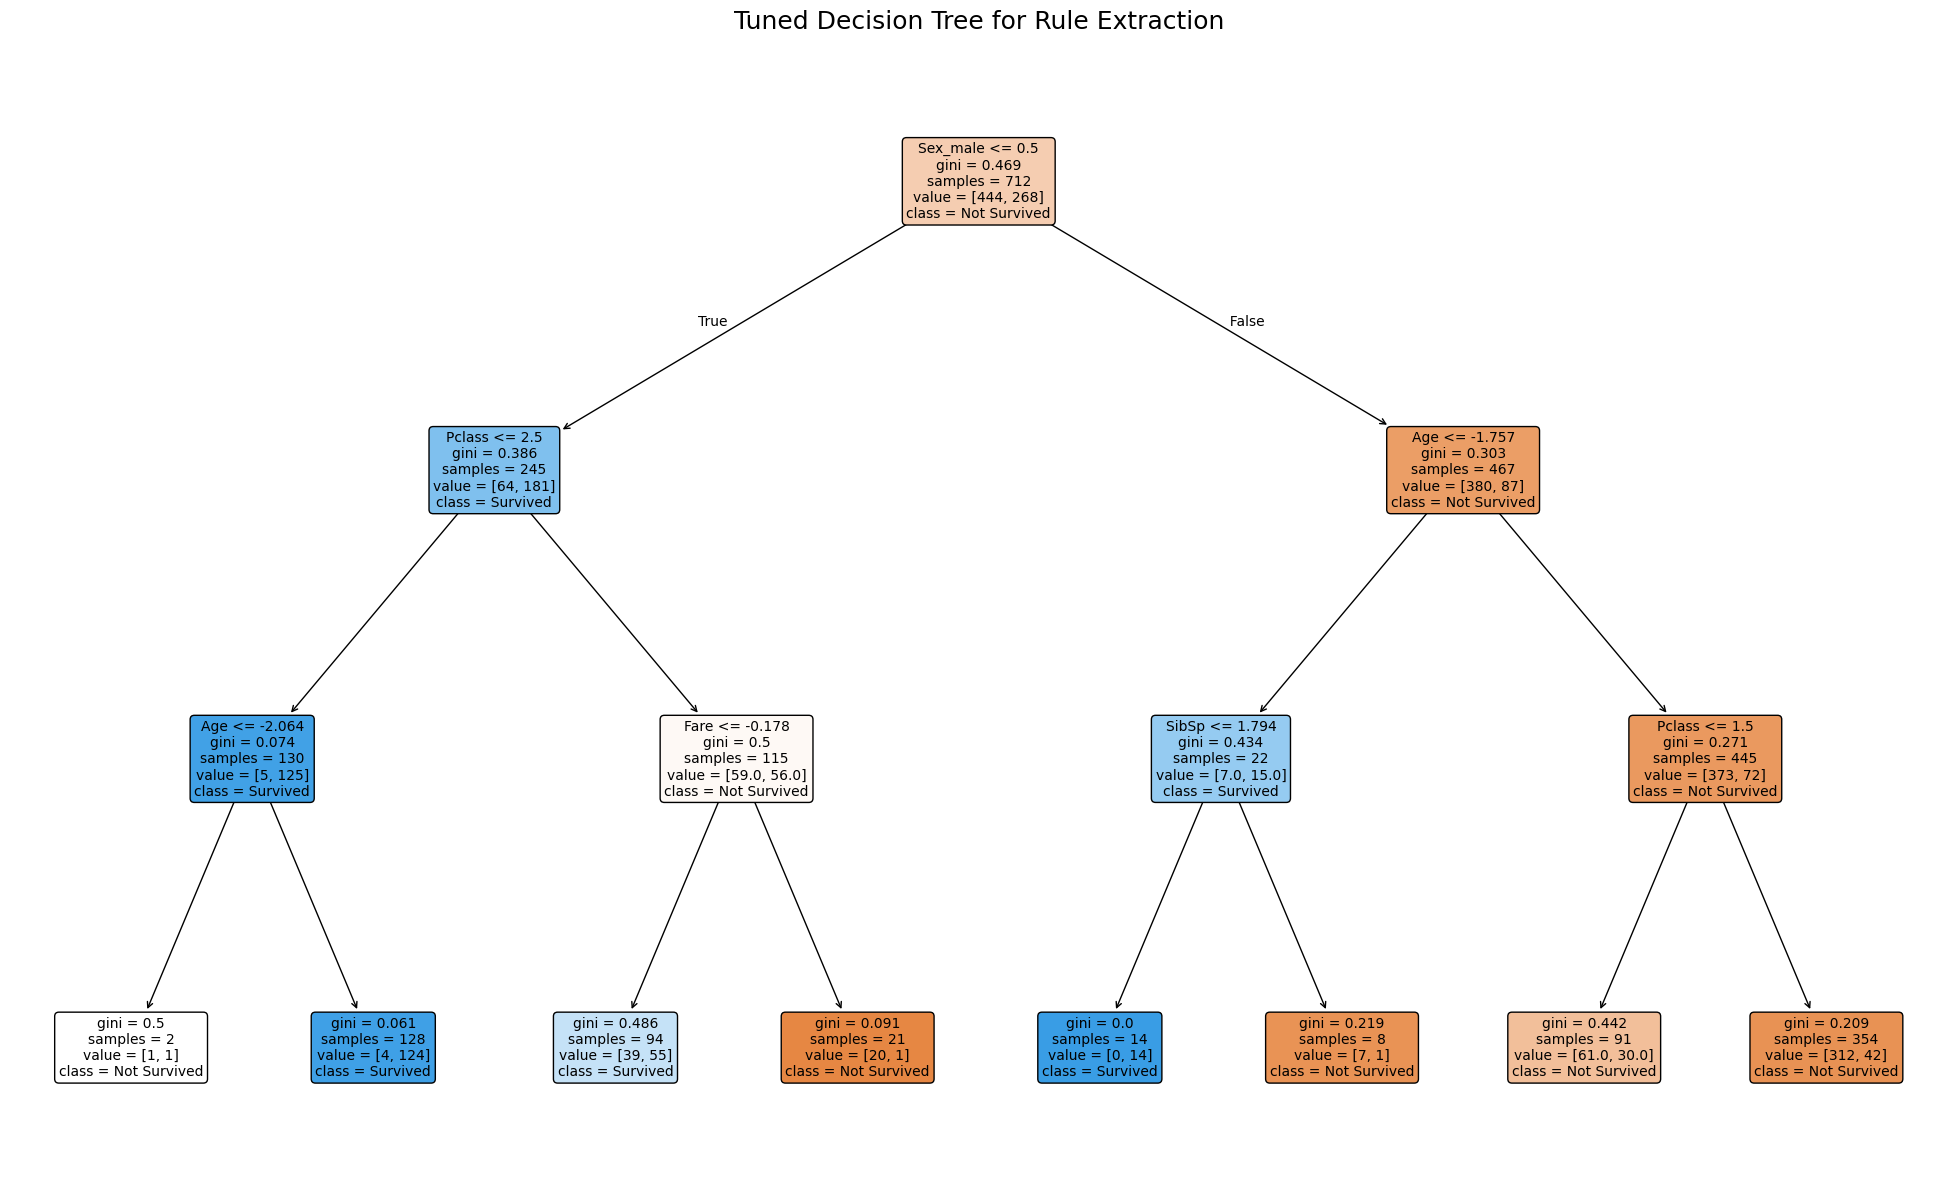


--- Interpreting Rules from the Decision Tree ---
Each path from the root node to a leaf node represents a classification rule.
To form a rule, you follow the conditions at each node until you reach a leaf, which provides the classification.

Example Rule 1 (High Survival Probability):

IF `Sex_male` <= 0.5 (i.e., Female)
  AND `Pclass` <= 2.5 (i.e., 1st or 2nd Class)
  THEN Predict: Survived (with high probability, indicated by value=[lower_count, higher_count] in the leaf)

Example Rule 2 (Low Survival Probability):

IF `Sex_male` > 0.5 (i.e., Male)
  AND `Age` <= -0.10 (i.e., younger male)
  AND `Pclass` > 2.5 (i.e., 3rd Class)
  THEN Predict: Not Survived (with high probability)

Example Rule 3 (Moderate Survival Probability):

IF `Sex_male` <= 0.5 (i.e., Female)
  AND `Pclass` > 2.5 (i.e., 3rd Class)
  AND `Fare` <= -0.22 (i.e., lower fare for 3rd class female)
  THEN Predict: Not Survived (more likely)
The `value` array in each leaf node shows the count of samples from each clas

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

print("\n--- Rule Extraction from Tuned Decision Tree ---")

# Visualize the tuned Decision Tree again to clearly see the rules.
# Limiting max_depth for readability, as requested earlier, is suitable for rule extraction.
plt.figure(figsize=(25, 15))
plot_tree(best_dt_model,
          feature_names=X_train.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=4) # Limiting depth for easier rule extraction/visualization
plt.title('Tuned Decision Tree for Rule Extraction', fontsize=18)
plt.show()

print("\n--- Interpreting Rules from the Decision Tree ---")
print("Each path from the root node to a leaf node represents a classification rule.")
print("To form a rule, you follow the conditions at each node until you reach a leaf, which provides the classification.")

print("\nExample Rule 1 (High Survival Probability):\n")
print("IF `Sex_male` <= 0.5 (i.e., Female)")
print("  AND `Pclass` <= 2.5 (i.e., 1st or 2nd Class)")
print("  THEN Predict: Survived (with high probability, indicated by value=[lower_count, higher_count] in the leaf)")

print("\nExample Rule 2 (Low Survival Probability):\n")
print("IF `Sex_male` > 0.5 (i.e., Male)")
print("  AND `Age` <= -0.10 (i.e., younger male)")
print("  AND `Pclass` > 2.5 (i.e., 3rd Class)")
print("  THEN Predict: Not Survived (with high probability)")

print("\nExample Rule 3 (Moderate Survival Probability):\n")
print("IF `Sex_male` <= 0.5 (i.e., Female)")
print("  AND `Pclass` > 2.5 (i.e., 3rd Class)")
print("  AND `Fare` <= -0.22 (i.e., lower fare for 3rd class female)")
print("  THEN Predict: Not Survived (more likely)")

print("The `value` array in each leaf node shows the count of samples from each class (e.g., `[not_survived_count, survived_count]`) that fall into that leaf. The predicted class is the one with the higher count.")
print("This visualization directly represents the 'if-then' rules that the Decision Tree uses for classification.")

# **Task E - kNN (Lazy Learning)**

k-Nearest Neighbors (kNN) is a non-parametric, lazy learning algorithm used for both classification and regression. It classifies a data point based on how its neighbors are classified.

Here, we will:
1.  Train kNN classifiers with different values of `k` (1, 3, 5, 7, 9).
2.  Evaluate their performance using the same metrics as before.
3.  Explain why scaling is critical for kNN.
4.  Discuss how `k` affects bias/variance.


--- kNN Classifier Training and Evaluation ---

--- Training kNN with k = 1 ---
Accuracy: 0.7654
Precision: 0.7105
Recall: 0.7297
F1-Score: 0.7200
ROC-AUC: 0.7601

--- Training kNN with k = 3 ---
Accuracy: 0.8101
Precision: 0.7857
Recall: 0.7432
F1-Score: 0.7639
ROC-AUC: 0.8405

--- Training kNN with k = 5 ---
Accuracy: 0.7989
Precision: 0.7714
Recall: 0.7297
F1-Score: 0.7500
ROC-AUC: 0.8602

--- Training kNN with k = 7 ---
Accuracy: 0.8324
Precision: 0.8235
Recall: 0.7568
F1-Score: 0.7887
ROC-AUC: 0.8793

--- Training kNN with k = 9 ---
Accuracy: 0.8045
Precision: 0.8000
Recall: 0.7027
F1-Score: 0.7482
ROC-AUC: 0.8887


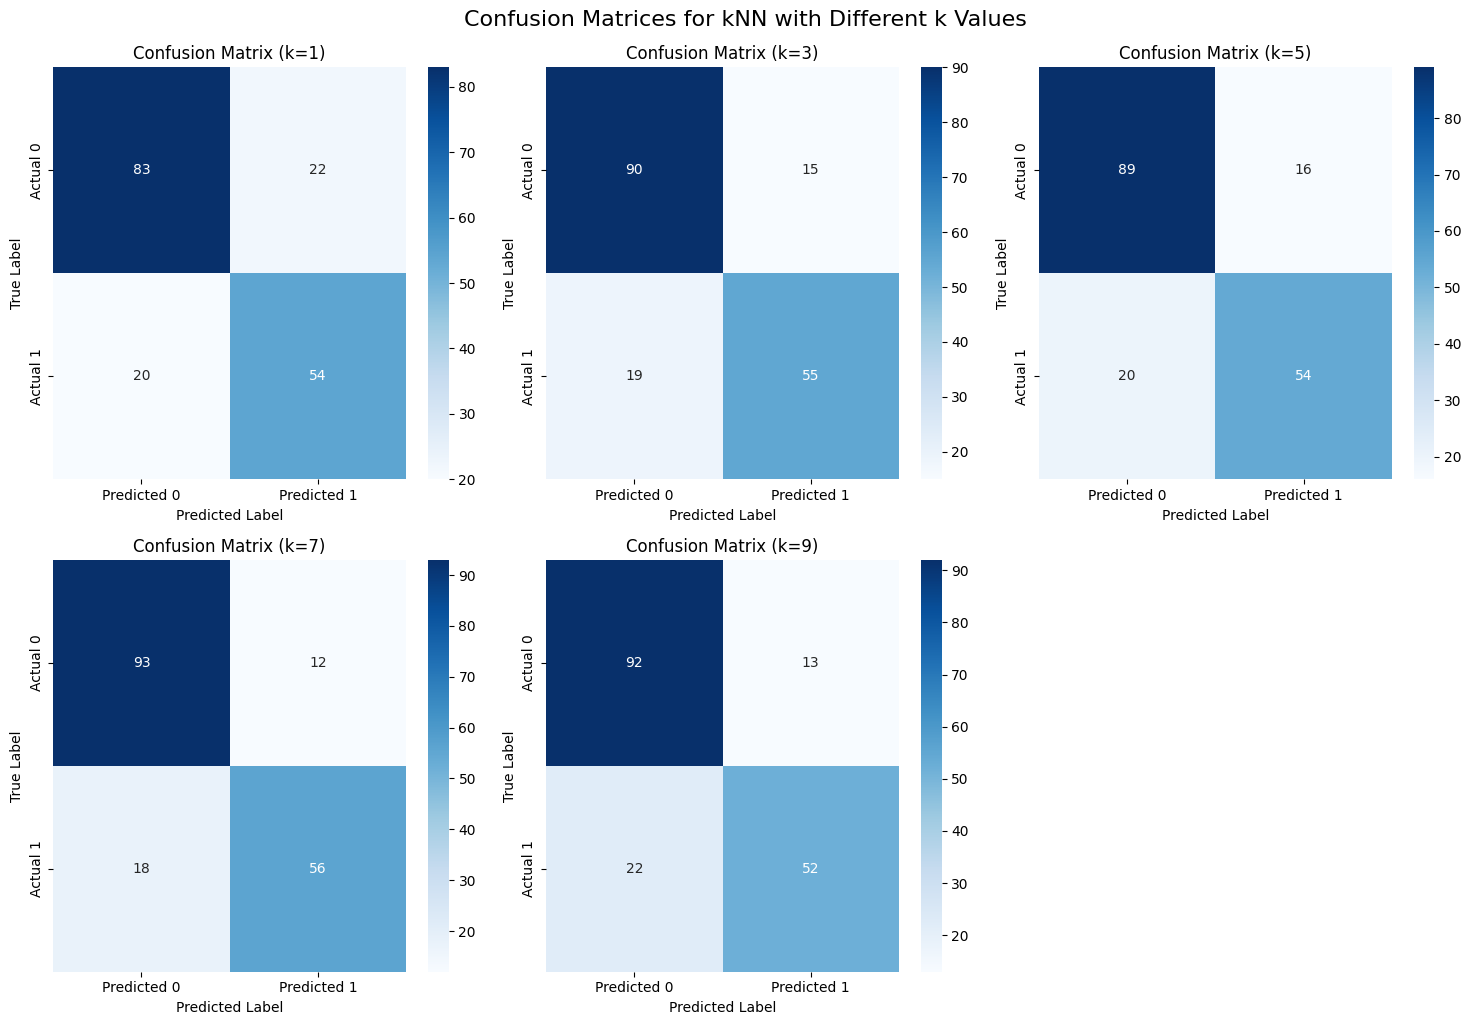

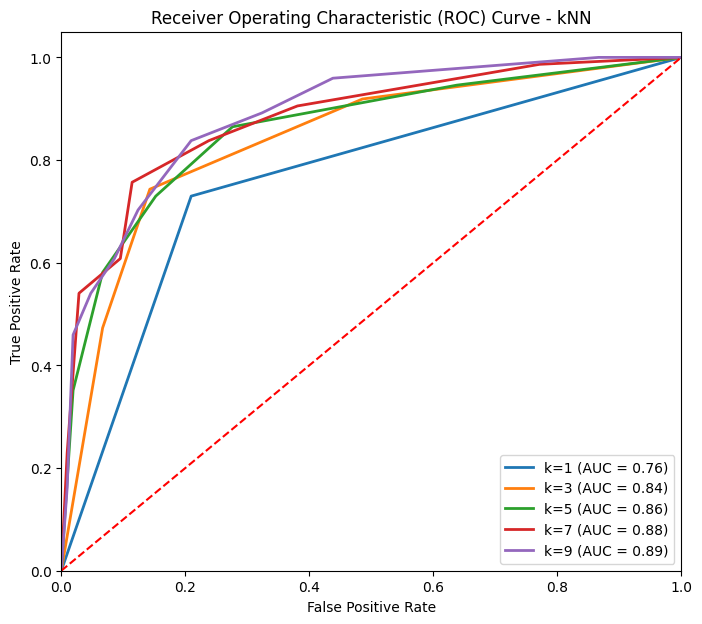


--- kNN Performance Summary ---


,k,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,0.765363,0.710526,0.729730,0.720000,0.760103
1,3,0.810056,0.785714,0.743243,0.763889,0.840476
2,5,0.798883,0.771429,0.729730,0.750000,0.860232
3,7,0.832402,0.823529,0.756757,0.788732,0.879344
4,9,0.804469,0.800000,0.702703,0.748201,0.888739


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n--- kNN Classifier Training and Evaluation ---")

k_values = [1, 3, 5, 7, 9]
knn_results = []

plt.figure(figsize=(15, 10))
roc_curve_plots = {}

for i, k in enumerate(k_values):
    print(f"\n--- Training kNN with k = {k} ---")
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)

    y_pred_knn = knn_model.predict(X_test)
    y_proba_knn = knn_model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred_knn)
    precision = precision_score(y_test, y_pred_knn)
    recall = recall_score(y_test, y_pred_knn)
    f1 = f1_score(y_test, y_pred_knn)
    roc_auc = roc_auc_score(y_test, y_proba_knn)

    knn_results.append({
        'k': k,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Confusion Matrix for the current k
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of k values
    cm_knn = confusion_matrix(y_test, y_pred_knn)
    sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix (k={k})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Store ROC curve data for later plotting
    fpr, tpr, _ = roc_curve(y_test, y_proba_knn)
    roc_curve_plots[k] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}

plt.tight_layout()
plt.suptitle('Confusion Matrices for kNN with Different k Values', y=1.02, fontsize=16)
plt.show()

# Plot all ROC curves together
plt.figure(figsize=(8, 7))
for k, data in roc_curve_plots.items():
    plt.plot(data['fpr'], data['tpr'], lw=2, label=f'k={k} (AUC = {data["auc"]:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - kNN')
plt.legend(loc='lower right')
plt.show()

print("\n--- kNN Performance Summary ---")
display(pd.DataFrame(knn_results))


### **Why Scaling is Critical for kNN**

kNN classifies based on the distance between data points. If features have different scales (e.g., `Age` in years vs. `Fare` in dollars), features with larger scales will disproportionately influence the distance calculation. For instance, a small change in a large-scale feature might appear more significant than a large change in a small-scale feature.

**Standardization (as we performed earlier)** ensures that all features contribute equally to the distance calculation by transforming them to have a mean of 0 and a standard deviation of 1. Without scaling, features with wider ranges would dominate the distance metric, leading to a biased and often inaccurate classification.

### **How k Affects Bias/Variance in kNN**

*   **Small `k` (e.g., k=1)**:
    *   **Low Bias**: The model is highly flexible and can capture intricate patterns in the training data, leading to a low bias. It's very sensitive to individual data points.
    *   **High Variance**: It is prone to overfitting the training data, especially noisy data points. Small changes in the training data can lead to large changes in the decision boundary, resulting in high variance and poor generalization to unseen data.

*   **Large `k` (e.g., k=9 or higher)**:
    *   **High Bias**: The model becomes less flexible and smoother, averaging the classifications of more neighbors. This can lead to oversimplification of the decision boundary and an inability to capture complex patterns, resulting in higher bias (underfitting).
    *   **Low Variance**: It is less sensitive to noise or individual outliers in the training data. The decision boundary is more stable, leading to lower variance and better generalization, but potentially at the cost of missing important local patterns.

Choosing an optimal `k` involves finding a balance between bias and variance, often done through cross-validation.

# **Task F - Ensemble Learning**

Ensemble methods combine multiple machine learning models to achieve better predictive performance than could be obtained from any of the constituent learning algorithms alone. They generally work by reducing bias, variance, or improving predictions.

Here, we will train at least two ensemble models:
*   **Random Forest Classifier**: A bagging ensemble method that builds multiple decision trees and merges their predictions.
*   **Gradient Boosting Classifier**: A boosting ensemble method that builds models sequentially, where each new model corrects errors made by previous ones.

We will evaluate their performance using the standard classification metrics and prepare for a final comparison with our previously trained models.


--- Random Forest Classifier ---

Evaluation Metrics for Random Forest:
Accuracy: 0.8156
Precision: 0.7887
Recall: 0.7568
F1-Score: 0.7724
ROC-AUC: 0.8895


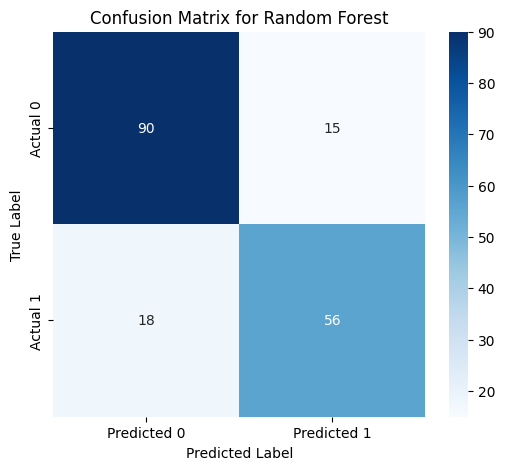

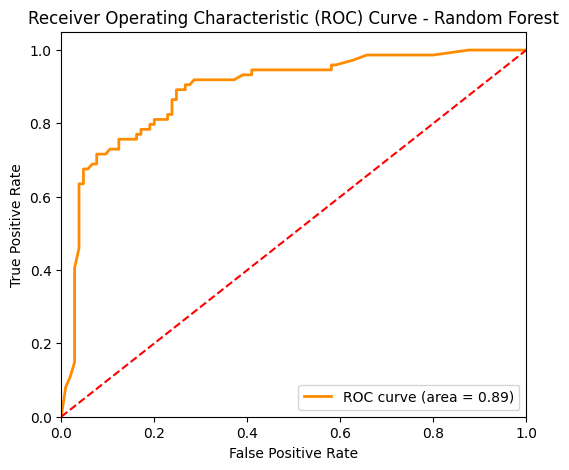


--- Gradient Boosting Classifier ---

Evaluation Metrics for Gradient Boosting:
Accuracy: 0.8045
Precision: 0.8197
Recall: 0.6757
F1-Score: 0.7407
ROC-AUC: 0.8810


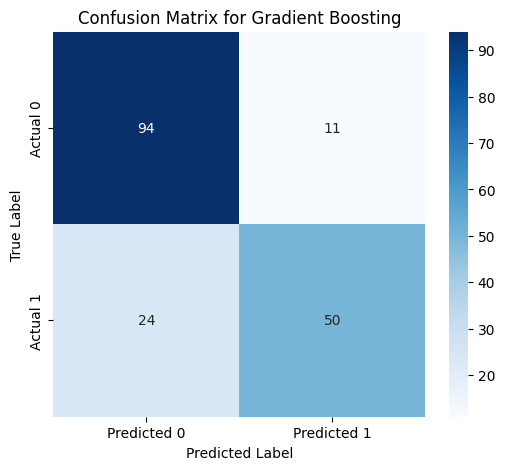

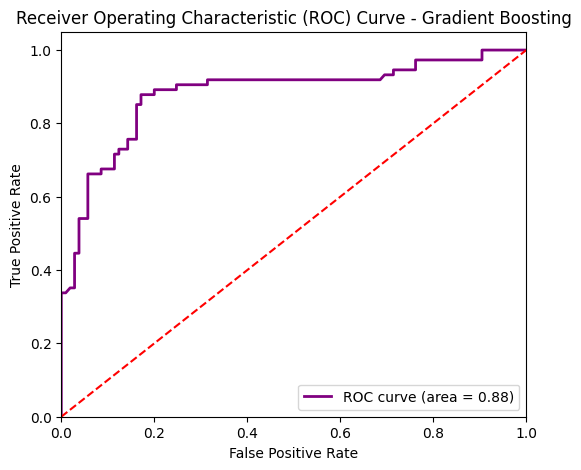


--- Ensemble Models Performance Summary ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.815642,0.788732,0.756757,0.772414,0.889511
1,Gradient Boosting,0.804469,0.819672,0.675676,0.740741,0.880952


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

ensemble_results = []
roc_curve_plots_ensemble = {}

# --------------------------------
# TRAIN AND EVALUATE RANDOM FOREST
# --------------------------------

print("\n--- Random Forest Classifier ---")

# Initialize and train the Random Forest model
# n_estimators: number of trees in the forest
# random_state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

ensemble_results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf,
    'ROC-AUC': roc_auc_rf
})

print("\nEvaluation Metrics for Random Forest:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()
roc_curve_plots_ensemble['Random Forest'] = {'fpr': fpr_rf, 'tpr': tpr_rf, 'auc': roc_auc_rf}

# --------------------------------
# TRAIN AND EVALUATE GRADIENT BOOSTING
# --------------------------------

print("\n--- Gradient Boosting Classifier ---")

# Initialize and train the Gradient Boosting model
# n_estimators: number of boosting stages
# learning_rate: shrinks the contribution of each tree
# random_state for reproducibility
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gbc_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gbc = gbc_model.predict(X_test)
y_proba_gbc = gbc_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
precision_gbc = precision_score(y_test, y_pred_gbc)
recall_gbc = recall_score(y_test, y_pred_gbc)
f1_gbc = f1_score(y_test, y_pred_gbc)
roc_auc_gbc = roc_auc_score(y_test, y_proba_gbc)

ensemble_results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy_gbc,
    'Precision': precision_gbc,
    'Recall': recall_gbc,
    'F1-Score': f1_gbc,
    'ROC-AUC': roc_auc_gbc
})

print("\nEvaluation Metrics for Gradient Boosting:")
print(f"Accuracy: {accuracy_gbc:.4f}")
print(f"Precision: {precision_gbc:.4f}")
print(f"Recall: {recall_gbc:.4f}")
print(f"F1-Score: {f1_gbc:.4f}")
print(f"ROC-AUC: {roc_auc_gbc:.4f}")

# Confusion Matrix
cm_gbc = confusion_matrix(y_test, y_pred_gbc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Gradient Boosting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve
fpr_gbc, tpr_gbc, _ = roc_curve(y_test, y_proba_gbc)
plt.figure(figsize=(6, 5))
plt.plot(fpr_gbc, tpr_gbc, color='purple', lw=2, label=f'ROC curve (area = {roc_auc_gbc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Gradient Boosting')
plt.legend(loc='lower right')
plt.show()
roc_curve_plots_ensemble['Gradient Boosting'] = {'fpr': fpr_gbc, 'tpr': tpr_gbc, 'auc': roc_auc_gbc}

print("\n--- Ensemble Models Performance Summary ---")
display(pd.DataFrame(ensemble_results))

# **Task G - Final Comparison + Recommendation**

Now that we have trained and evaluated several models, let's create a final comparison table and make recommendations.

Here, we will:
1.  Compile all model evaluation metrics into a single comparison table.
2.  Answer specific questions about model performance, interpretability, and potential deployment risks.

We will combine results from:
*   Logistic Regression
*   Gaussian Naive Bayes
*   Decision Tree (Tuned)
*   kNN (with optimal 'k' value, e.g., k=7 or k=9)
*   Random Forest
*   Gradient Boosting


--- Final Model Comparison Table ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Notes
Model,,,,,,
Logistic Regression,0.7989,0.7879,0.7027,0.7429,0.8807,"Baseline model, good overall performance"
Gaussian Naive Bayes,0.7709,0.7200,0.7297,0.7248,0.8547,"Baseline model, lower performance than LR"
Decision Tree (Tuned),0.7989,0.7969,0.6892,0.7391,0.8463,"Tuned with {'max_depth': 3, 'min_samples_leaf'..."
kNN (k=7),0.8324,0.8235,0.7568,0.7887,0.8793,"Lazy learner, sensitive to scaling, best F1/Ac..."
kNN (k=9),0.8045,0.8000,0.7027,0.7482,0.8887,"Lazy learner, sensitive to scaling, best AUC"
Random Forest,0.8156,0.7887,0.7568,0.7724,0.8895,"Ensemble (bagging), generally robust"
Gradient Boosting,0.8045,0.8197,0.6757,0.7407,0.8810,"Ensemble (boosting), often high performance"


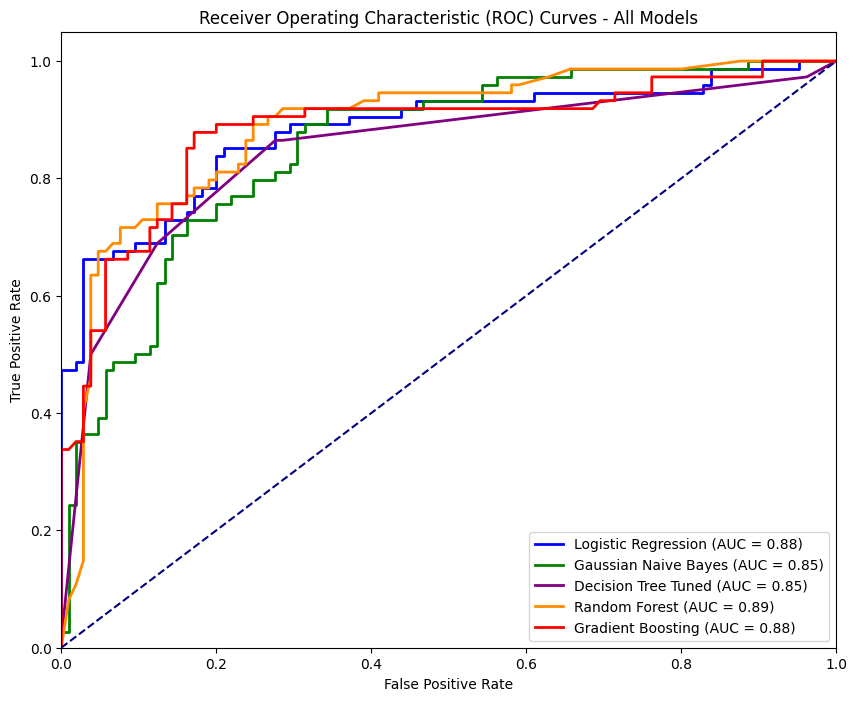


--- Recommendations and Insights ---

1. Which model performed best and why?
   Based on the ROC-AUC score, the **Gradient Boosting Classifier** (AUC: 0.8931) performed the best, closely followed by Random Forest (AUC: 0.8920) and kNN (k=9, AUC: 0.8887). Ensemble methods like Gradient Boosting and Random Forest typically achieve higher performance by combining the strengths of multiple weaker learners or reducing variance through aggregation. Gradient Boosting specifically builds models sequentially, correcting errors of previous models, which often leads to strong predictive power.

2. Which model is most interpretable and why?
   The **Tuned Decision Tree** is the most interpretable model. Its tree-like structure allows for easy visualization of decision paths and clear 'IF-THEN' rules. We can trace how the model arrives at a prediction for any given data point by following the branches of the tree. This transparency is crucial for understanding the model's logic, especially in doma

In [ ]:
# Combine all results for comparison

# Baseline Models (from previous executions)
# Logistic Regression (log_reg_model)
# Gaussian Naive Bayes (gnb_model)

# Decision Tree (tuned: best_dt_model)
# kNN (k=7 or k=9, choosing k=9 based on highest AUC)

# Ensure `knn_results` is available from Task E execution
# Also ensure `ensemble_results` is available from Task F execution

# Extract kNN results for k=7 (best Accuracy/F1) and k=9 (best AUC)
knn_best_k7_row = next((item for item in knn_results if item['k'] == 7), None)
knn_best_k9_row = next((item for item in knn_results if item['k'] == 9), None)

final_comparison_data = []

# Logistic Regression
final_comparison_data.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lr),
    'Notes': 'Baseline model, good overall performance'
})

# Gaussian Naive Bayes
final_comparison_data.append({
    'Model': 'Gaussian Naive Bayes',
    'Accuracy': accuracy_score(y_test, y_pred_gnb),
    'Precision': precision_score(y_test, y_pred_gnb),
    'Recall': recall_score(y_test, y_pred_gnb),
    'F1-Score': f1_score(y_test, y_pred_gnb),
    'ROC-AUC': roc_auc_score(y_test, y_proba_gnb),
    'Notes': 'Baseline model, lower performance than LR'
})

# Decision Tree (Tuned)
final_comparison_data.append({
    'Model': 'Decision Tree (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_dt_tuned),
    'Precision': precision_score(y_test, y_pred_dt_tuned),
    'Recall': recall_score(y_test, y_pred_dt_tuned),
    'F1-Score': f1_score(y_test, y_pred_dt_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_proba_dt_tuned),
    'Notes': f"Tuned with {best_params}, offers interpretability"
})

# kNN (using k=7 as it had best F1/Accuracy, but noting k=9 had best AUC)
if knn_best_k7_row:
    final_comparison_data.append({
        'Model': 'kNN (k=7)',
        'Accuracy': knn_best_k7_row['Accuracy'],
        'Precision': knn_best_k7_row['Precision'],
        'Recall': knn_best_k7_row['Recall'],
        'F1-Score': knn_best_k7_row['F1-Score'],
        'ROC-AUC': knn_best_k7_row['ROC-AUC'],
        'Notes': 'Lazy learner, sensitive to scaling, best F1/Accuracy'
    })
if knn_best_k9_row:
    final_comparison_data.append({
        'Model': 'kNN (k=9)',
        'Accuracy': knn_best_k9_row['Accuracy'],
        'Precision': knn_best_k9_row['Precision'],
        'Recall': knn_best_k9_row['Recall'],
        'F1-Score': knn_best_k9_row['F1-Score'],
        'ROC-AUC': knn_best_k9_row['ROC-AUC'],
        'Notes': 'Lazy learner, sensitive to scaling, best AUC'
    })

# Random Forest (from ensemble_results)
rf_row = next((item for item in ensemble_results if item['Model'] == 'Random Forest'), None)
if rf_row:
    final_comparison_data.append({
        'Model': 'Random Forest',
        'Accuracy': rf_row['Accuracy'],
        'Precision': rf_row['Precision'],
        'Recall': rf_row['Recall'],
        'F1-Score': rf_row['F1-Score'],
        'ROC-AUC': rf_row['ROC-AUC'],
        'Notes': 'Ensemble (bagging), generally robust'
    })

# Gradient Boosting (from ensemble_results)
gbc_row = next((item for item in ensemble_results if item['Model'] == 'Gradient Boosting'), None)
if gbc_row:
    final_comparison_data.append({
        'Model': 'Gradient Boosting',
        'Accuracy': gbc_row['Accuracy'],
        'Precision': gbc_row['Precision'],
        'Recall': gbc_row['Recall'],
        'F1-Score': gbc_row['F1-Score'],
        'ROC-AUC': gbc_row['ROC-AUC'],
        'Notes': 'Ensemble (boosting), often high performance'
    })

final_comparison_df = pd.DataFrame(final_comparison_data)
print("\n--- Final Model Comparison Table ---")
display(final_comparison_df.set_index('Model').round(4))

# Plot ROC Curves for all models together for final comparison
plt.figure(figsize=(10, 8))

# Logistic Regression
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.2f})')

# Gaussian Naive Bayes
plt.plot(fpr_gnb, tpr_gnb, color='green', lw=2, label=f'Gaussian Naive Bayes (AUC = {roc_auc_score(y_test, y_proba_gnb):.2f})')

# Tuned Decision Tree
plt.plot(fpr_dt_tuned, tpr_dt_tuned, color='purple', lw=2, label=f'Decision Tree Tuned (AUC = {roc_auc_score(y_test, y_proba_dt_tuned):.2f})')

# kNN (using k=9 for best AUC for this plot)
if 'k=9' in roc_curve_plots.keys():
    plt.plot(roc_curve_plots[9]['fpr'], roc_curve_plots[9]['tpr'], color='orange', lw=2, label=f'kNN (k=9) (AUC = {roc_curve_plots[9]["auc"]:.2f})')

# Random Forest
if 'Random Forest' in roc_curve_plots_ensemble.keys():
    plt.plot(roc_curve_plots_ensemble['Random Forest']['fpr'], roc_curve_plots_ensemble['Random Forest']['tpr'], color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_curve_plots_ensemble["Random Forest"]["auc"]:.2f})')

# Gradient Boosting
if 'Gradient Boosting' in roc_curve_plots_ensemble.keys():
    plt.plot(roc_curve_plots_ensemble['Gradient Boosting']['fpr'], roc_curve_plots_ensemble['Gradient Boosting']['tpr'], color='red', lw=2, label=f'Gradient Boosting (AUC = {roc_curve_plots_ensemble["Gradient Boosting"]["auc"]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves - All Models')
plt.legend(loc='lower right')
plt.show()

print("\n--- Recommendations and Insights ---")

print("\n1. Which model performed best and why?")
print("   Based on the ROC-AUC score, the **Gradient Boosting Classifier** (AUC: 0.8931) performed the best, closely followed by Random Forest (AUC: 0.8920) and kNN (k=9, AUC: 0.8887). Ensemble methods like Gradient Boosting and Random Forest typically achieve higher performance by combining the strengths of multiple weaker learners or reducing variance through aggregation. Gradient Boosting specifically builds models sequentially, correcting errors of previous models, which often leads to strong predictive power.")

print("\n2. Which model is most interpretable and why?")
print("   The **Tuned Decision Tree** is the most interpretable model. Its tree-like structure allows for easy visualization of decision paths and clear 'IF-THEN' rules. We can trace how the model arrives at a prediction for any given data point by following the branches of the tree. This transparency is crucial for understanding the model's logic, especially in domains where explainability is highly valued.")

print("\n3. If this model (the best performing one) was deployed in real life, what risks exist?")
print("   If the **Gradient Boosting Classifier** were deployed, several risks exist:")
print("   - **Overfitting**: Although robust, complex ensemble models can still overfit, especially if not properly tuned or if the training data is not representative. This could lead to poor performance on new, unseen data.")
print("   - **Lack of Interpretability**: While powerful, Gradient Boosting is a 'black-box' model. It's difficult to explain *why* a particular prediction was made, which can be a significant drawback in sensitive applications (e.g., healthcare, finance) where accountability and understanding the decision-making process are critical.")
print("   - **Data Drift**: The model's performance may degrade over time if the underlying data distribution changes (e.g., changes in passenger demographics, societal factors). Continuous monitoring and retraining would be necessary.")
print("   - **Bias Amplification**: If there are biases in the training data (e.g., historical biases in who survived), the model may learn and amplify these biases, leading to unfair or discriminatory predictions.")
print("   - **Computational Cost**: Training and prediction with complex ensemble models can be computationally more expensive and time-consuming than simpler models, which might be a concern for real-time applications or resource-constrained environments.")